# 04 Pipeline — Análise Quantitativa (F4)

Demonstra e valida a Etapa 4 (F4): contagem de pixels, percentual afetado, classificação de severidade, histograma do canal H e o painel final — tudo integrado através de `process_image()` (F4.6), o pipeline completo F1→F4.

Fluxo por trás de `process_image`: `load_image` → `preprocess` → `bgr_to_hsv` → `segment_leaf` + `extract_largest_contour` → `detect_lesions` → `analyze` → `create_result_panel`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from plant_disease.config import SELECTED_DATA_DIR
from plant_disease.pipeline import process_image, PipelineConfig

%matplotlib inline

print("✓ Imports OK")

✓ Imports OK


In [2]:
# Seleciona algumas imagens de cada categoria disponível para demonstração
categories = [
    "tomato_healthy",
    "tomato_early_blight",
    "tomato_late_blight",
    "potato_healthy",
    "potato_early_blight",
    "potato_late_blight",
]

extensoes_validas = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
demo_paths = []

for category in categories:
    cat_dir = SELECTED_DATA_DIR / category
    if not cat_dir.exists():
        continue
    count = 0
    for arquivo in sorted(cat_dir.iterdir()):
        if arquivo.suffix.lower() in extensoes_validas:
            demo_paths.append((arquivo, category))
            count += 1
        if count >= 2:
            break

print(f"✓ {len(demo_paths)} imagens selecionadas para demonstração do pipeline")

✓ 12 imagens selecionadas para demonstração do pipeline


## Demonstração: painel completo por imagem

`process_image()` já retorna a `Figure` pronta em `"panel"` (F4.5) — basta exibi-la.

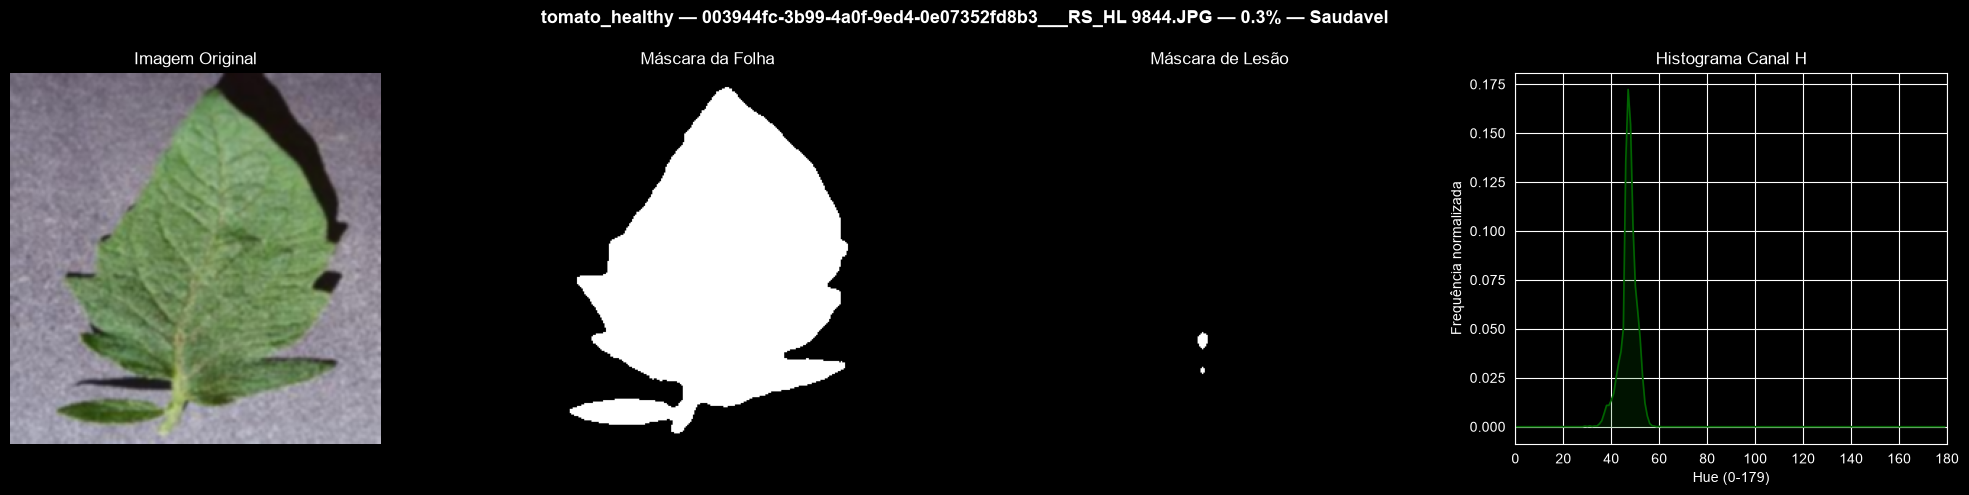

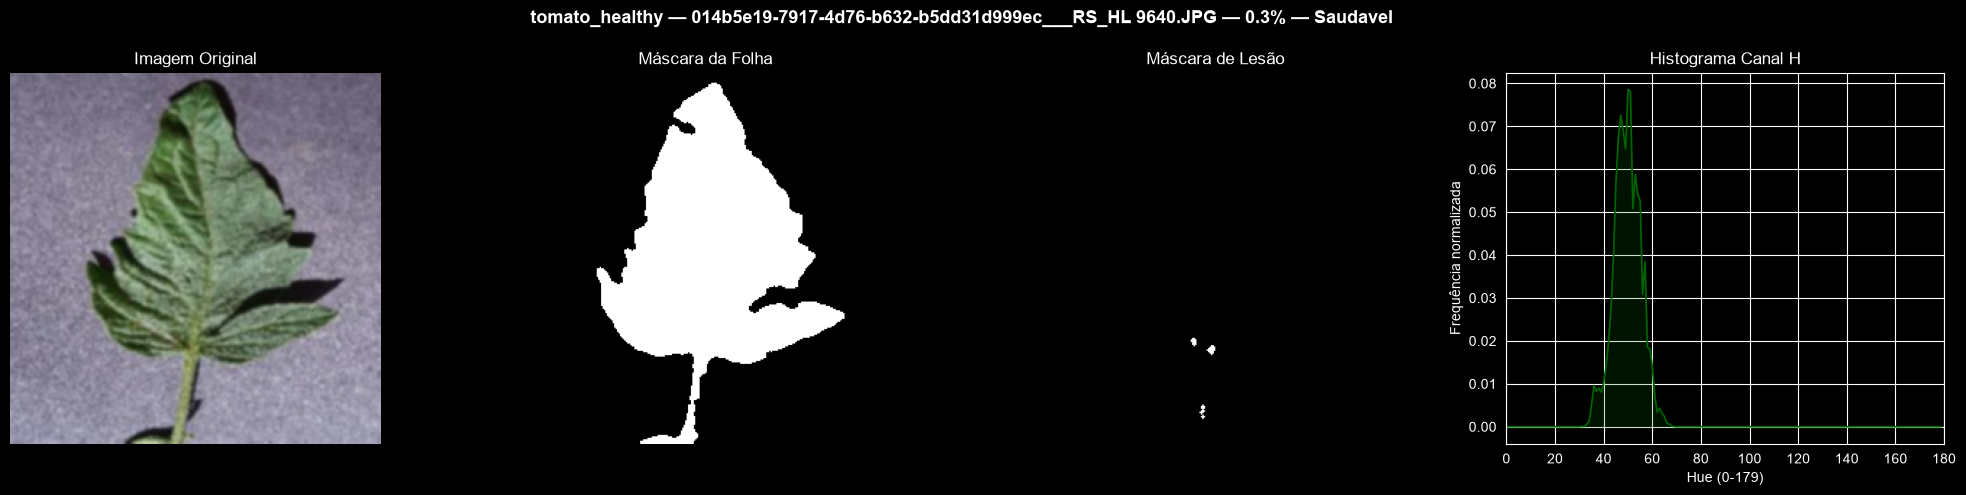

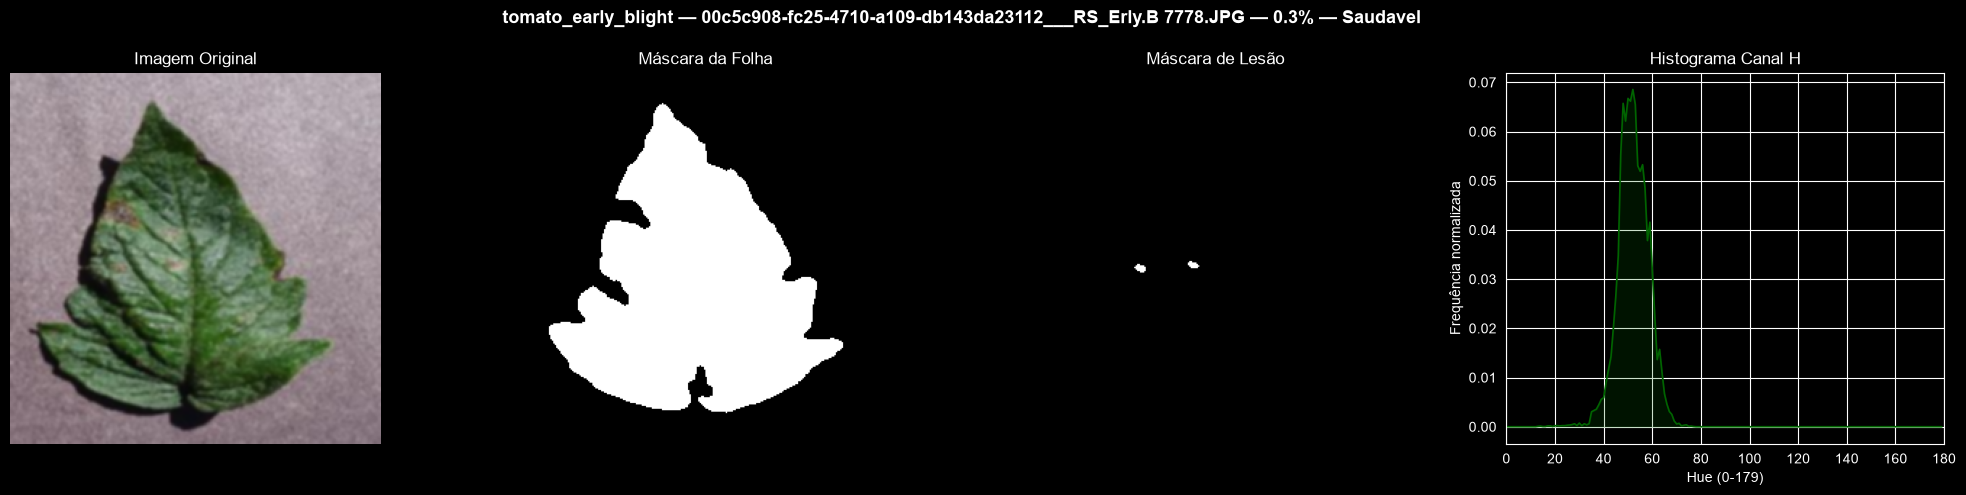

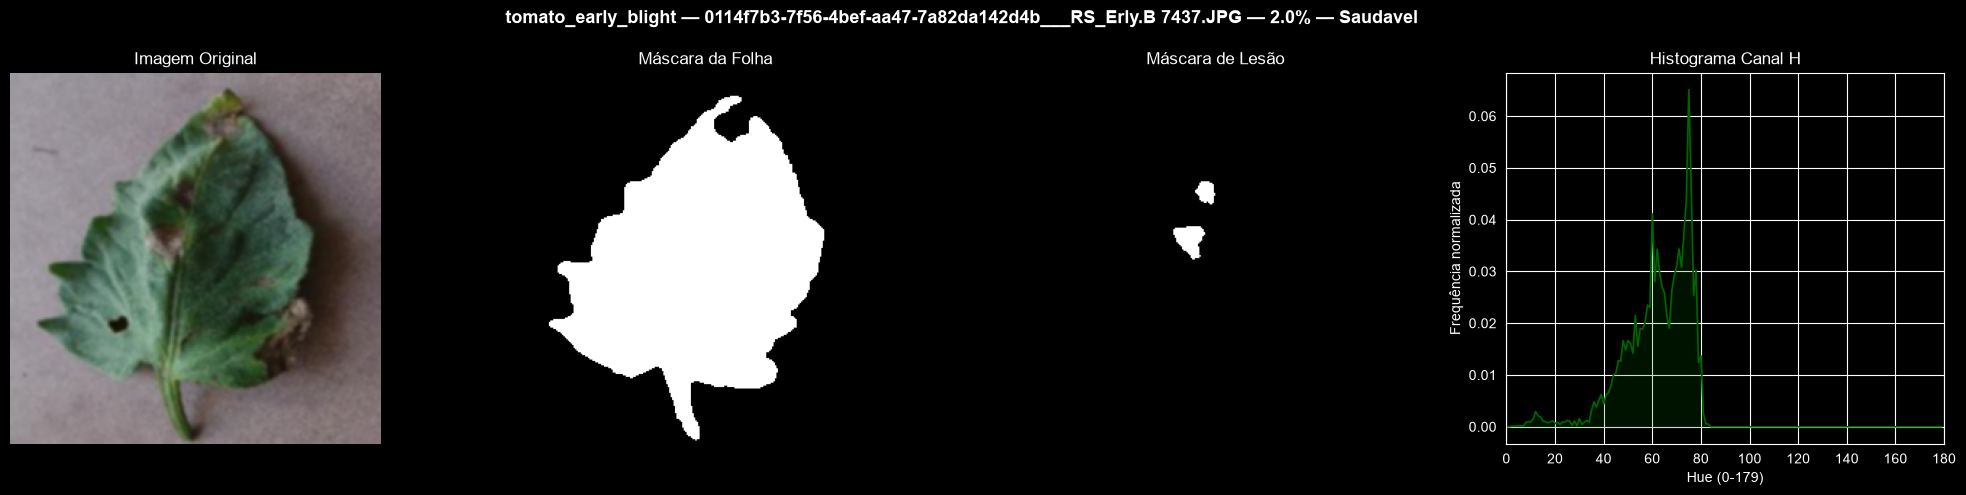

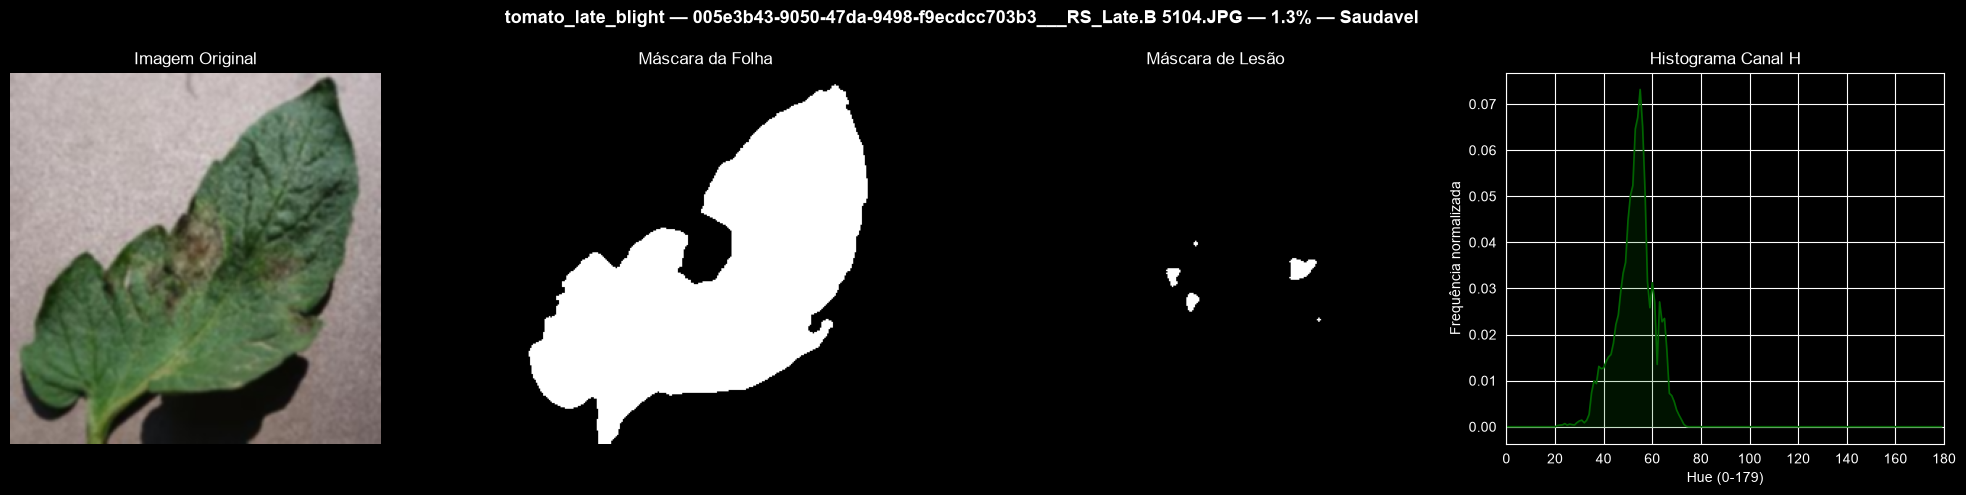

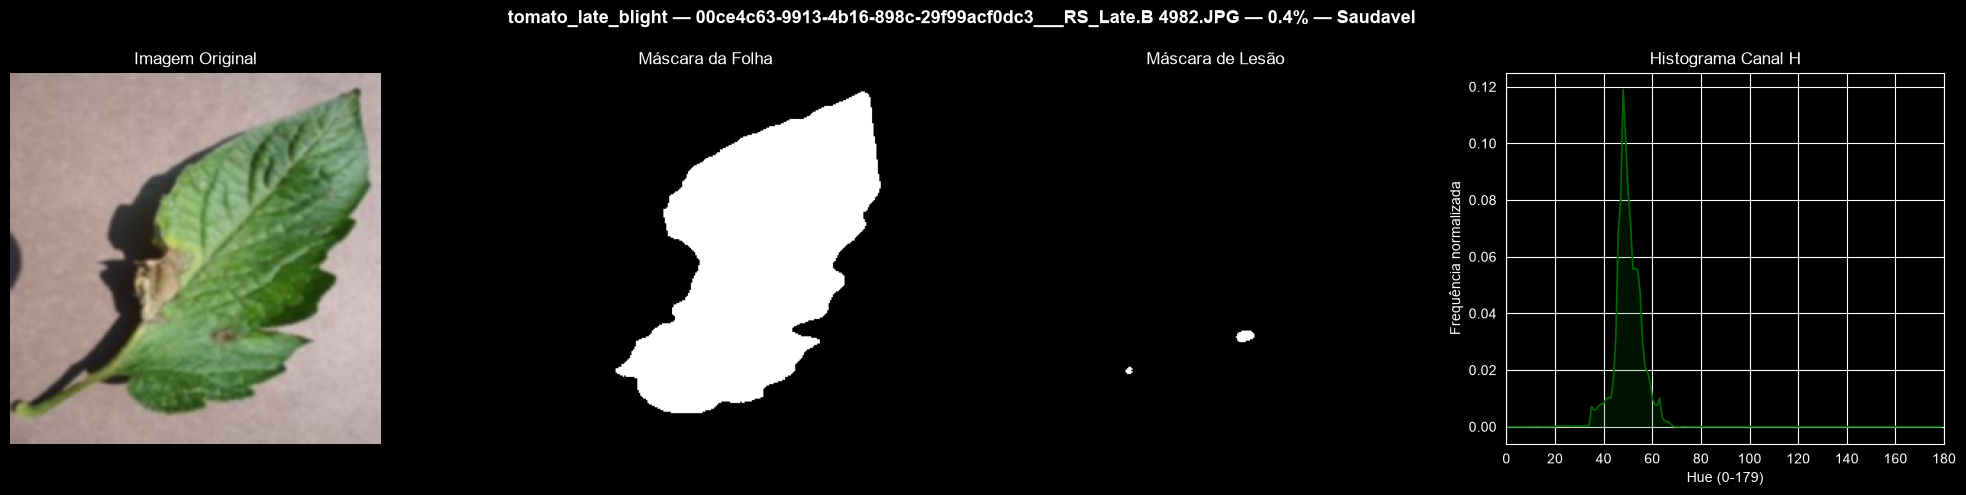

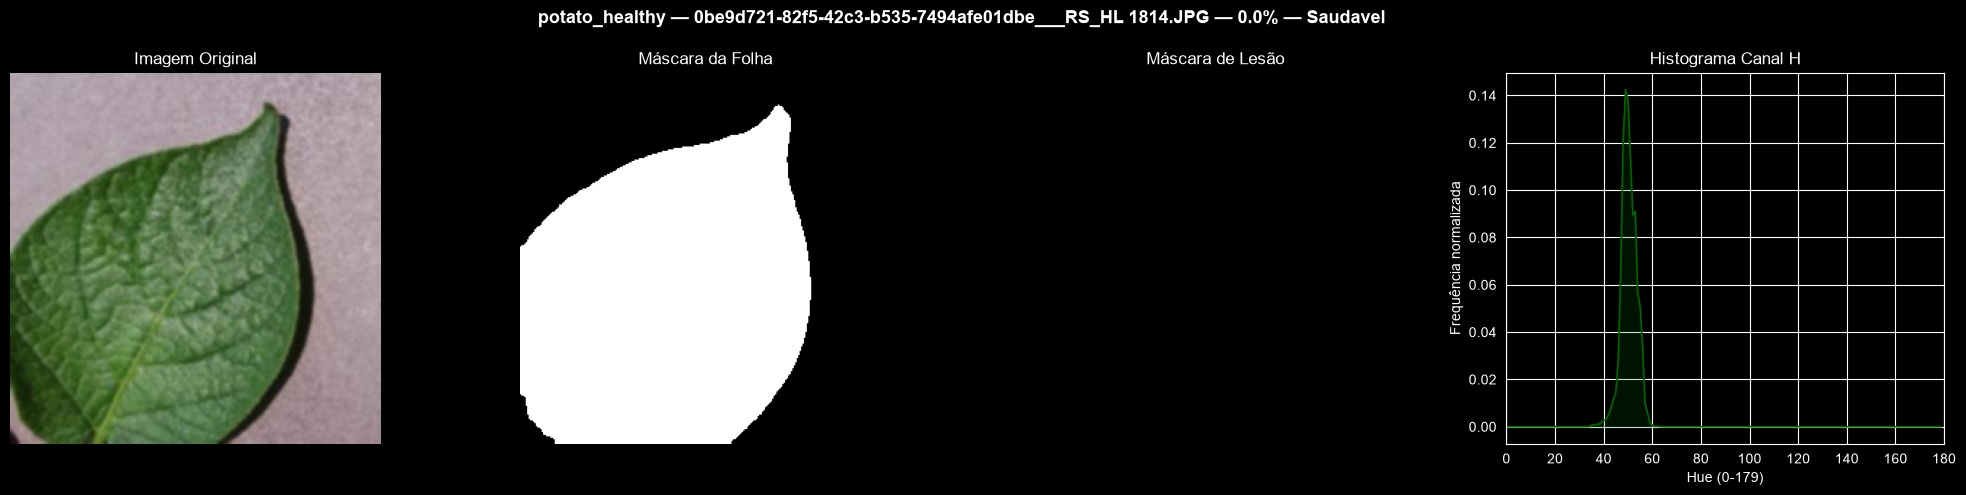

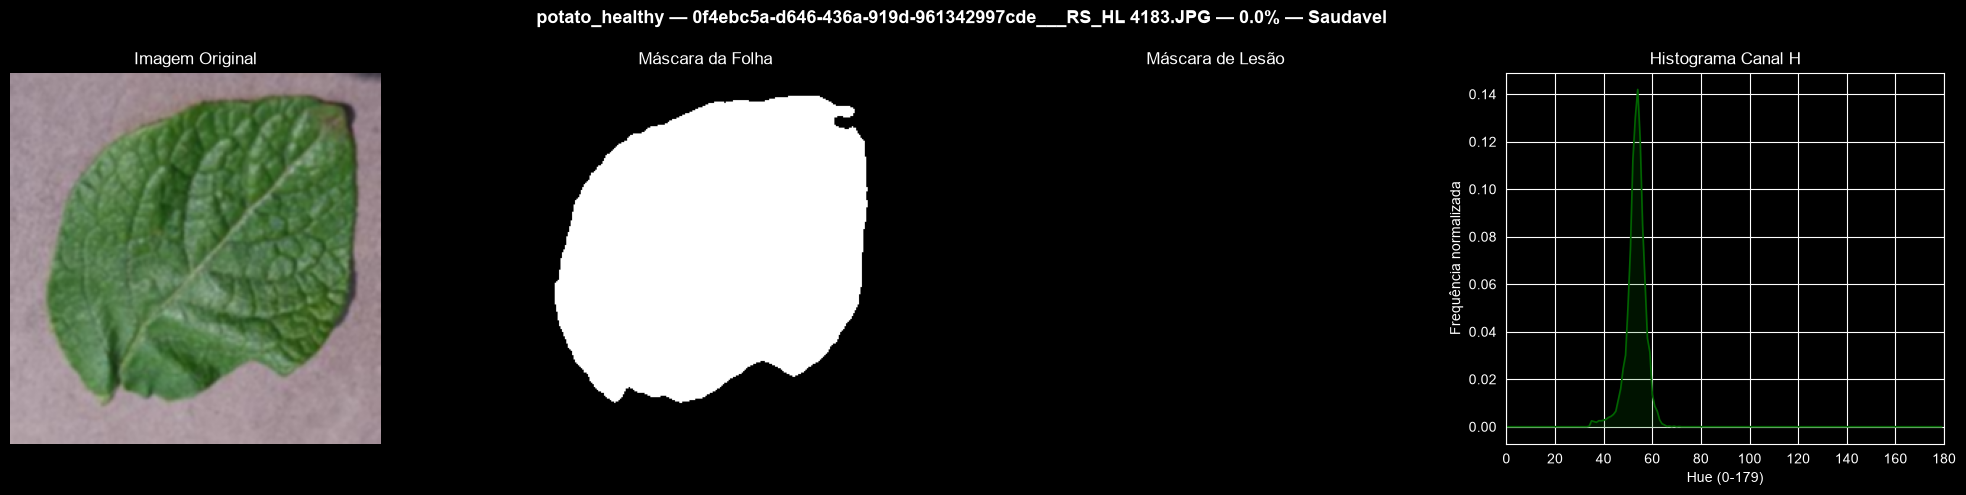

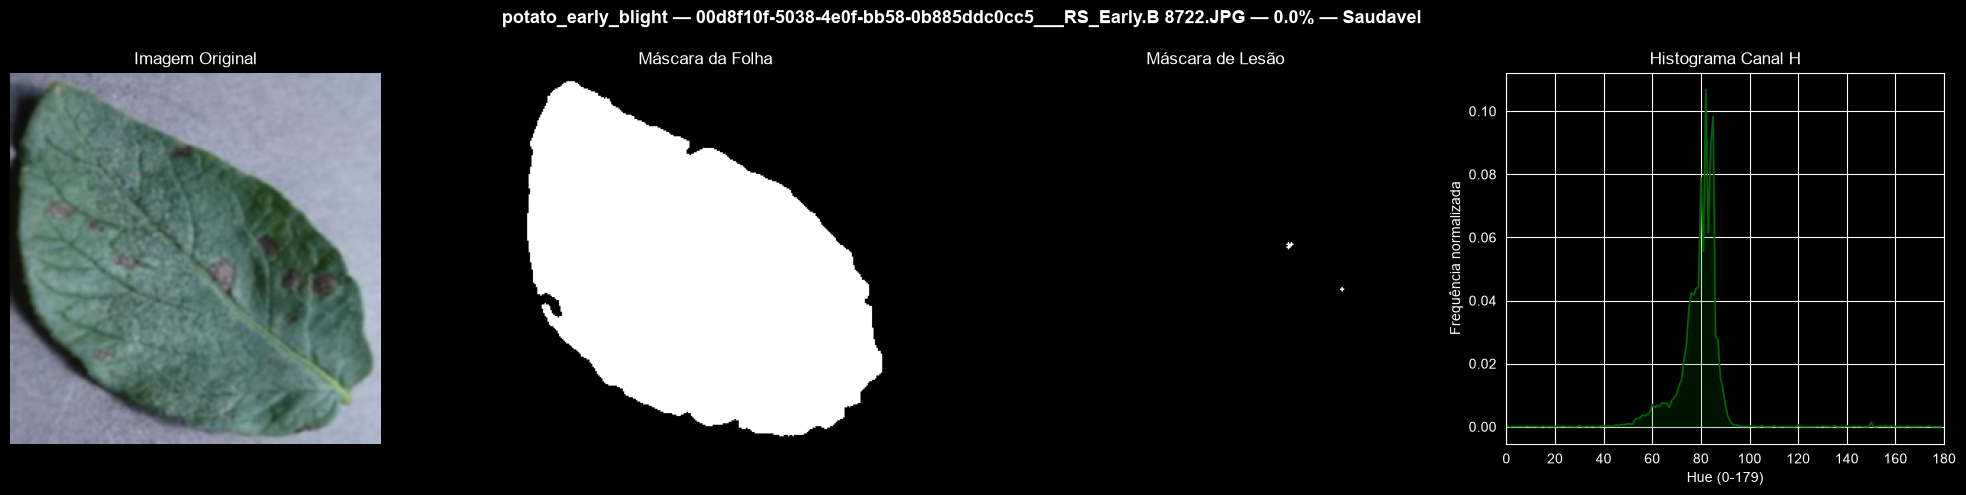

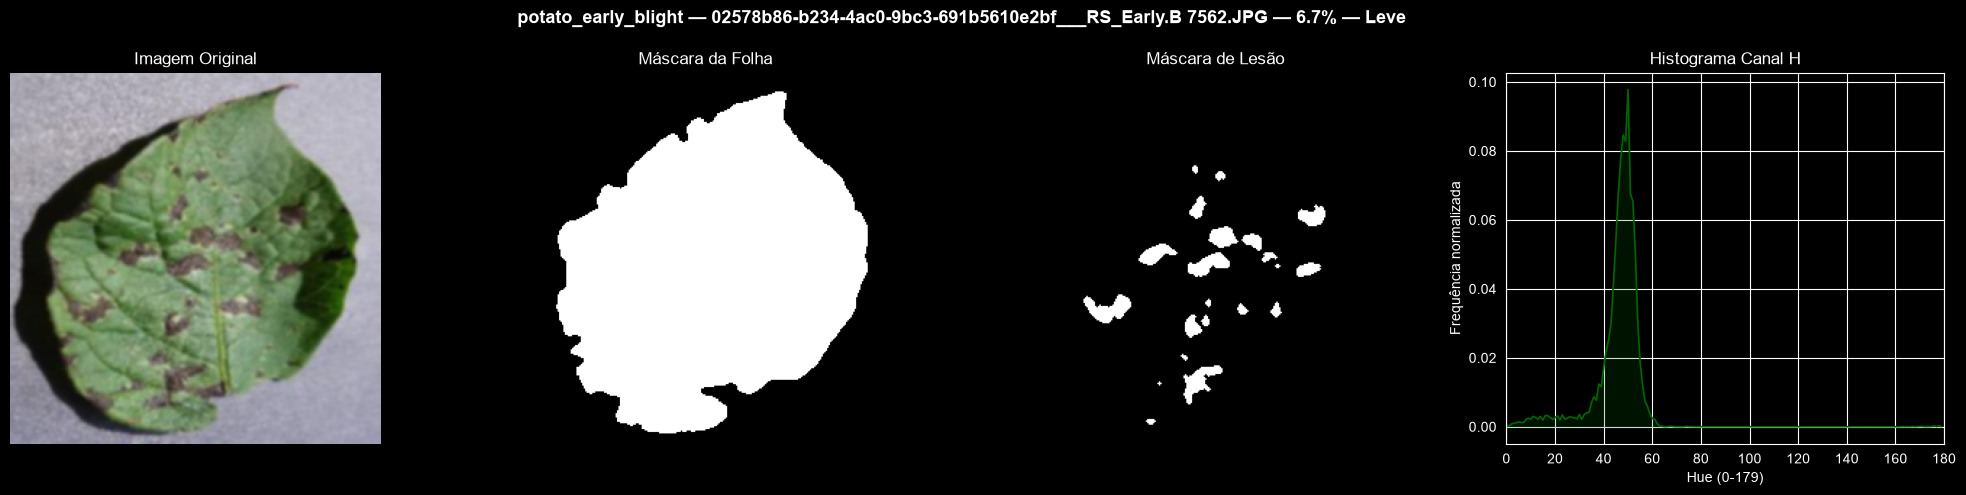

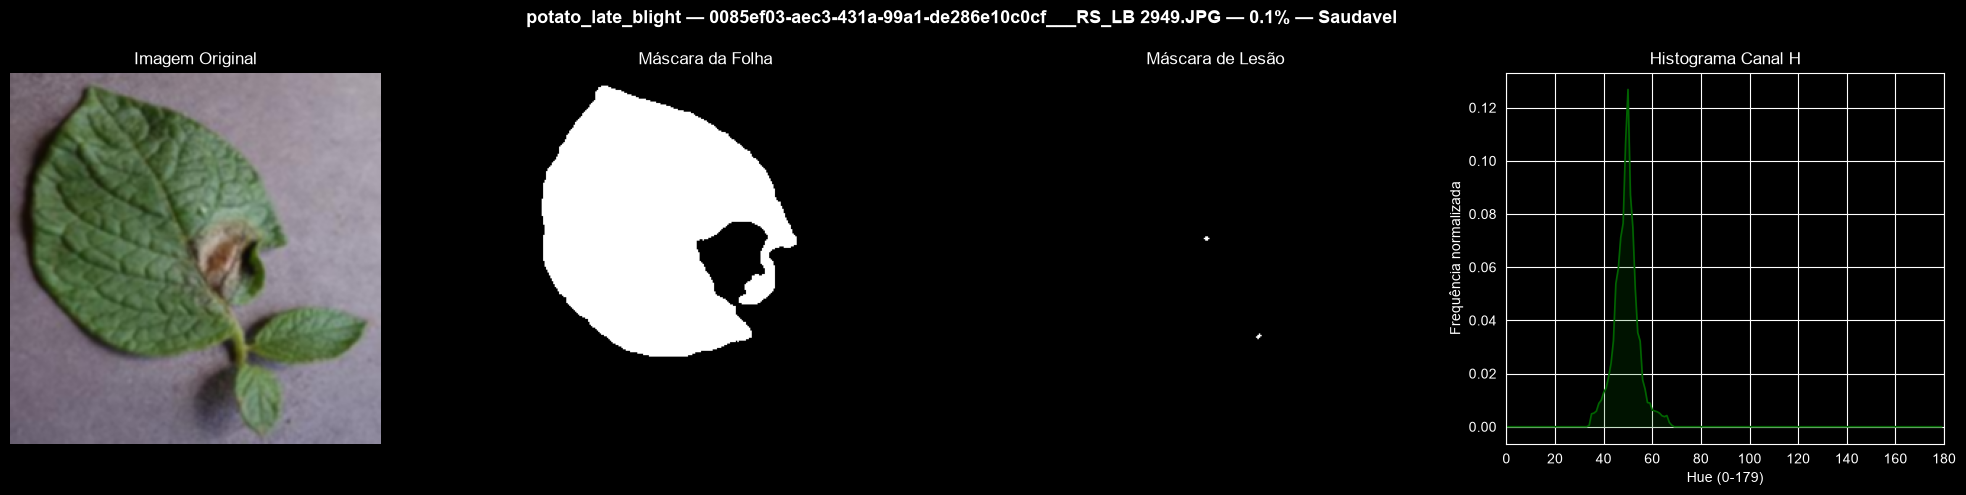

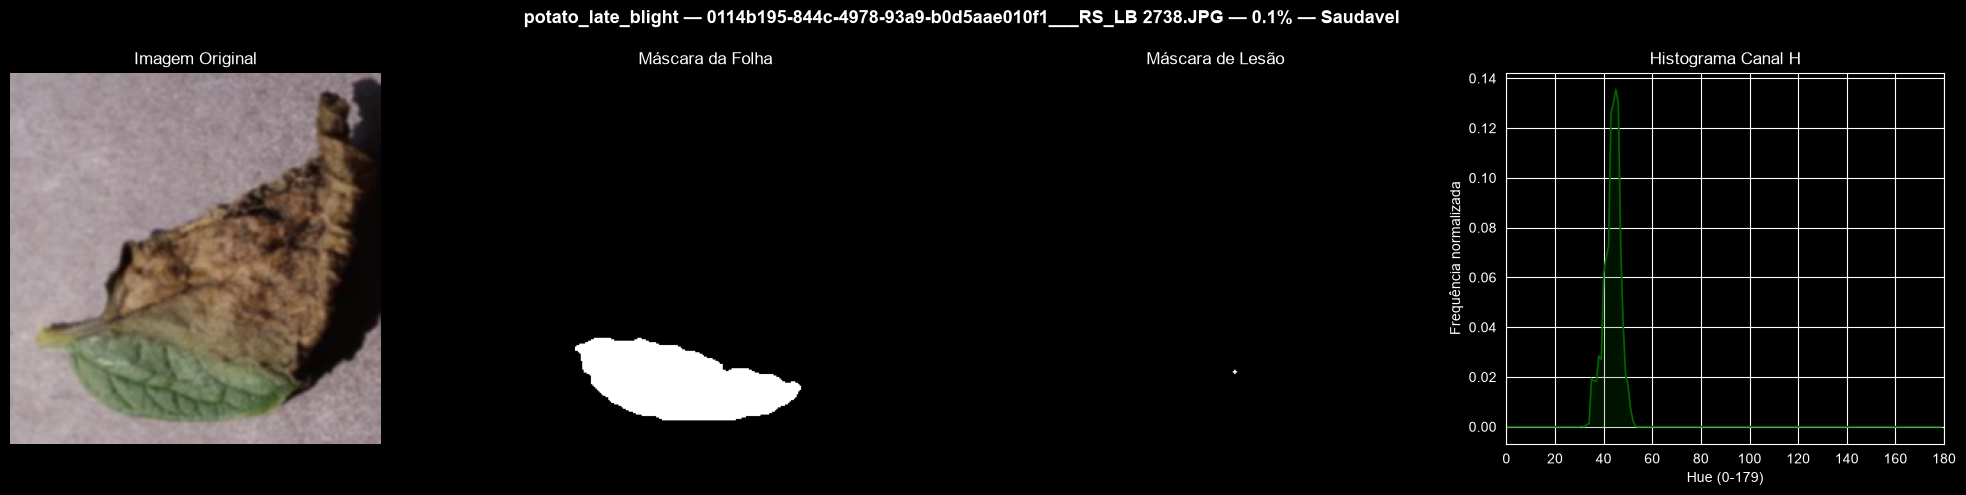

In [3]:
for path, category in demo_paths:
    result = process_image(str(path))

    if result["error"] is not None:
        print(f"[ERRO] {path.name} ({category}): {result['error']}")
        continue

    if result["panel"] is not None:
        result["panel"].suptitle(
            f"{category} — {path.name} — "
            f"{result['pct_affected']:.1f}% — {result['severity']}",
            fontsize=13,
            fontweight="bold",
        )
        plt.show()

## Validação dos critérios de pronto da F4.6

- `process_image(path)` executa sem erro em pelo menos 10 imagens.
- O dict de retorno tem todas as chaves esperadas.
- A máscara de lesão está sempre contida na máscara da folha.
- Folhas saudáveis classificam como `Saudavel` com percentual baixo.

In [4]:
import cv2

EXPECTED_KEYS = {
    "image", "leaf_mask", "lesion_mask", "leaf_px", "lesion_px",
    "pct_affected", "severity", "contours", "panel", "error",
}

linhas = []
n_erros = 0
n_fora_da_folha = 0

# Usamos gerar_painel=False aqui só para a checagem em lote ser mais rápida
# (o painel de cada imagem já foi mostrado na célula anterior).
config_rapida = PipelineConfig(gerar_painel=False)

for path, category in demo_paths:
    result = process_image(str(path), config=config_rapida)

    assert set(result.keys()) == EXPECTED_KEYS, f"Chaves inesperadas em {path}"

    if result["error"] is not None:
        n_erros += 1
        linhas.append({
            "image": path.name, "category": category,
            "leaf_px": None, "lesion_px": None,
            "pct_affected": None, "severity": "Erro",
            "error": result["error"],
        })
        continue

    fora_da_folha = cv2.countNonZero(
        cv2.bitwise_and(result["lesion_mask"], cv2.bitwise_not(result["leaf_mask"]))
    )
    if fora_da_folha > 0:
        n_fora_da_folha += 1

    linhas.append({
        "image": path.name, "category": category,
        "leaf_px": result["leaf_px"], "lesion_px": result["lesion_px"],
        "pct_affected": round(result["pct_affected"], 2),
        "severity": result["severity"], "error": None,
    })

df = pd.DataFrame(linhas)
display(df)

print(f"\nImagens processadas: {len(demo_paths)} | erros: {n_erros} | lesão fora da folha: {n_fora_da_folha}")
print(f"Status: {'✓ PASSED' if n_erros == 0 and n_fora_da_folha == 0 else '✗ VERIFICAR ACIMA'}")

saudaveis = df[df["category"].str.contains("healthy") & df["error"].isna()]
if len(saudaveis) > 0:
    print(f"Percentual médio em folhas saudáveis: {saudaveis['pct_affected'].mean():.2f}% (esperado baixo)")
    print(f"Classificações em saudáveis: {saudaveis['severity'].unique().tolist()} (esperado só 'Saudavel')")

,image,category,leaf_px,lesion_px,pct_affected,severity,error
0,003944fc-3b99-4a0f-9ed4-0e07352fd8b3___RS_HL 9...,tomato_healthy,27000,71,0.26,Saudavel,None
1,014b5e19-7917-4d76-b632-b5dd31d999ec___RS_HL 9...,tomato_healthy,18459,62,0.34,Saudavel,None
2,00c5c908-fc25-4710-a109-db143da23112___RS_Erly...,tomato_early_blight,23016,59,0.26,Saudavel,None
3,0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly...,tomato_early_blight,23989,478,1.99,Saudavel,None
4,005e3b43-9050-47da-9498-f9ecdcc703b3___RS_Late...,tomato_late_blight,27876,369,1.32,Saudavel,None
5,00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late...,tomato_late_blight,22497,97,0.43,Saudavel,None
6,0be9d721-82f5-42c3-b535-7494afe01dbe___RS_HL 1...,potato_healthy,36069,0,0.00,Saudavel,None
7,0f4ebc5a-d646-436a-919d-961342997cde___RS_HL 4...,potato_healthy,36114,0,0.00,Saudavel,None
8,00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Earl...,potato_early_blight,39619,19,0.05,Saudavel,None
9,02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Earl...,potato_early_blight,34229,2277,6.65,Leve,None



Imagens processadas: 12 | erros: 0 | lesão fora da folha: 0
Status: ✓ PASSED
Percentual médio em folhas saudáveis: 0.15% (esperado baixo)
Classificações em saudáveis: ['Saudavel'] (esperado só 'Saudavel')


## Nota sobre performance em lote

`PipelineConfig(gerar_painel=False)` evita criar uma `Figure` do matplotlib para cada imagem — importante quando a F5 rodar o pipeline em 50-300 imagens de uma vez. Para uso exploratório em notebook, o padrão (`gerar_painel=True`) é o mais conveniente, pois já entrega o painel pronto em `result["panel"]`.

## Próximo passo (F5)

Este notebook cobre a demonstração exigida pela F4. A execução em lote (50+ imagens), a análise de falsos positivos/negativos e a tabela consolidada (`results/csv_results.csv`) são objeto da **F5 — Validação**, ainda não implementada.